In [1]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold

import albumentations as A
from albumentations.pytorch import ToTensorV2

from monai.losses import TverskyLoss
from monai.losses import DiceLoss

from torch.utils.data import WeightedRandomSampler


import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt
import segmentation_models_pytorch as smp
from torch.amp import autocast, GradScaler


device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f'Using device: {device}')

2026-03-04 22:07:18.980334: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 22:07:19.212247: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 22:07:20.362553: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/fffeelipe/.conda/envs/torch_cuda/lib/python3.11/site-packages/keras/src/export/tf2onn

Using device: cuda


In [2]:
# Define paths
DATA_DIR = './T1/'
IMAGE_DIR = './images/'
MASK_DIR = './masks/'

# Create directories if they don't exist
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# Get a list of patient folders
patient_folders = sorted(glob.glob(os.path.join(DATA_DIR, 'IOG*')))

In [3]:
import json

SLICE_MAP_PATH = 'slice_tumor_map.json'

def extract_and_save_slices(patient_folders, image_dir, mask_dir):
    """Extract slices and create a map tracking which have tumor segmentation."""
    slice_tumor_map = {}  # filename -> has_tumor (bool)
    
    for patient_folder in patient_folders:
        patient_id = os.path.basename(patient_folder)
        try:
            img_path = glob.glob(os.path.join(patient_folder, '*[!_roi].nii.gz'))[0]
            mask_path = glob.glob(os.path.join(patient_folder, '*_roi.nii.gz'))[0]

            img = nib.load(img_path).get_fdata()
            mask = nib.load(mask_path).get_fdata()

            # Normalize image to 0-255 and convert to uint8
            img = ((img - np.min(img)) / (np.max(img) - np.min(img)) * 255).astype(np.uint8)
            mask = (mask > 0).astype(np.uint8) * 255 # Binarize mask

            # Assuming axial slices are the last dimension
            for i in range(img.shape[2]):
                img_slice = Image.fromarray(img[:, :, i])
                mask_slice = Image.fromarray(mask[:, :, i])
                
                filename = f'{patient_id}_slice_{i}.png'
                has_tumor = bool(np.sum(np.array(mask_slice)) > 0)
                slice_tumor_map[filename] = has_tumor
                
                img_slice.save(os.path.join(image_dir, filename))
                mask_slice.save(os.path.join(mask_dir, filename))
                
        except IndexError:
            print(f'Skipping {patient_id} due to missing files.')
    
    # Save the map
    with open(SLICE_MAP_PATH, 'w') as f:
        json.dump(slice_tumor_map, f)
    
    pos = sum(slice_tumor_map.values())
    neg = len(slice_tumor_map) - pos
    print(f'Saved {len(slice_tumor_map)} slices: {pos} with tumor, {neg} without')
    return slice_tumor_map

# Skip extraction if data already exists
if os.path.exists(SLICE_MAP_PATH) and os.path.exists(IMAGE_DIR) and len(os.listdir(IMAGE_DIR)) > 0:
    print(f'Loading existing slice_tumor_map from {SLICE_MAP_PATH}')
    with open(SLICE_MAP_PATH, 'r') as f:
        slice_tumor_map = json.load(f)
    pos = sum(slice_tumor_map.values())
    neg = len(slice_tumor_map) - pos
    print(f'Loaded {len(slice_tumor_map)} slices: {pos} with tumor, {neg} without')
else:
    slice_tumor_map = extract_and_save_slices(patient_folders, IMAGE_DIR, MASK_DIR)
    print('Finished extracting and saving slices.')


Loading existing slice_tumor_map from slice_tumor_map.json
Loaded 1806 slices: 870 with tumor, 936 without


Dataset balance: 870 positive, 936 negative slices


/tmp/ipykernel_17491/1730961300.py:14: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
/tmp/ipykernel_17491/1730961300.py:21: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),


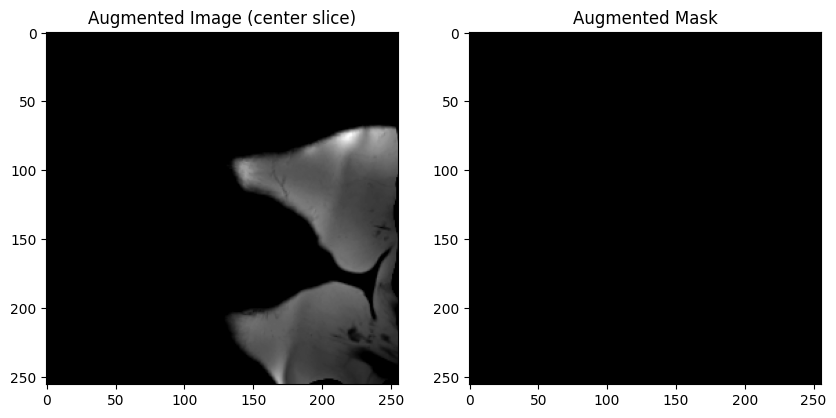

In [4]:
# 2.5D slice gap: how many slices apart to sample neighbors (1=adjacent, 2=skip-one, etc.)
SLICE_GAP = 1

# ImageNet normalization — matches the pretrained encoder's expected input distribution
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Define the augmentation pipeline for the training set (3-channel for 2.5D)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
    A.Affine(
        rotate=(-15, 15),
        scale=(0.9, 1.1),
        translate_percent=0.05,
        p=0.75
    ),
    A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Define a simpler pipeline for the validation set (no augmentations)
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# Load the slice tumor map
def load_slice_tumor_map():
    if os.path.exists(SLICE_MAP_PATH):
        with open(SLICE_MAP_PATH, 'r') as f:
            return json.load(f)
    return {}

slice_tumor_map = load_slice_tumor_map()

import re

def build_patient_slice_index(image_paths):
    """Build a mapping from patient_id -> {slice_idx: filepath} for neighbor lookup."""
    patient_slices = {}
    for p in image_paths:
        fname = os.path.basename(p)
        m = re.match(r'^(.+)_slice_(\d+)\.png$', fname)
        if m:
            pid, sidx = m.group(1), int(m.group(2))
            patient_slices.setdefault(pid, {})[sidx] = p
    return patient_slices

class LipomaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, slice_tumor_map=None,
                 global_patient_slices=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.slice_tumor_map = slice_tumor_map or {}

        # Use global index (all slices) so neighbors are always available,
        # even when this dataset is a subset (e.g. only positives).
        self.patient_slices = global_patient_slices or build_patient_slice_index(image_paths)

        # Pre-compute per-sample: (patient_id, slice_idx, max_slice_idx)
        self.sample_info = []
        for img_path in self.image_paths:
            fname = os.path.basename(img_path)
            m = re.match(r'^(.+)_slice_(\d+)\.png$', fname)
            pid, sidx = m.group(1), int(m.group(2))
            max_idx = max(self.patient_slices[pid].keys())
            self.sample_info.append((pid, sidx, max_idx))

        # Build has_tumor flags for each sample
        self.has_tumor = []
        for img_path in self.image_paths:
            filename = os.path.basename(img_path)
            self.has_tumor.append(self.slice_tumor_map.get(filename, True))

    def __len__(self):
        return len(self.image_paths)

    def _load_gray(self, path):
        return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]
        pid, sidx, max_idx = self.sample_info[idx]
        slices_map = self.patient_slices[pid]

        # Neighbor indices with boundary clamping (gap-based)
        prev_idx = max(sidx - SLICE_GAP, 0)
        next_idx = min(sidx + SLICE_GAP, max_idx)

        # Load 3 slices (prev, center, next) and stack as H x W x 3
        s_prev = self._load_gray(slices_map[prev_idx])
        s_curr = self._load_gray(slices_map[sidx])
        s_next = self._load_gray(slices_map[next_idx])
        image = np.stack([s_prev, s_curr, s_next], axis=-1)  # H x W x 3

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8) * 255

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        mask = (mask > 0.5).float().unsqueeze(0)

        return image, mask
    
    def get_balanced_sampler(self, neg_to_pos_ratio=1.0):
        """Create a WeightedRandomSampler to balance positive/negative samples.
        
        Args:
            neg_to_pos_ratio: Target ratio of negative to positive samples (1.0 = equal)
        """
        n_pos = sum(self.has_tumor)
        n_neg = len(self.has_tumor) - n_pos
        
        if n_pos == 0 or n_neg == 0:
            return None
        
        weight_pos = 1.0
        weight_neg = (n_pos / n_neg) * neg_to_pos_ratio
        
        weights = [weight_pos if has_tumor else weight_neg for has_tumor in self.has_tumor]
        
        return WeightedRandomSampler(
            weights=weights,
            num_samples=len(weights),
            replacement=True
        )

# Create a placeholder dataset to get all image/mask paths
all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))
all_masks = sorted(glob.glob(os.path.join(MASK_DIR, '*.png')))

# Global patient slice index — shared across all dataset instances so
# neighbor slices are always available even in subset datasets.
global_patient_slices = build_patient_slice_index(all_images)

# Report balance
if slice_tumor_map:
    n_pos = sum(1 for img in all_images if slice_tumor_map.get(os.path.basename(img), True))
    n_neg = len(all_images) - n_pos
    print(f'Dataset balance: {n_pos} positive, {n_neg} negative slices')


# Demonstrate the augmentation by showing an example
if len(all_images) > 0:
    temp_dataset = LipomaDataset(image_paths=all_images, mask_paths=all_masks, 
                                  transform=train_transform, slice_tumor_map=slice_tumor_map,
                                  global_patient_slices=global_patient_slices)
    image, mask = temp_dataset[0]
    
    # Reverse ImageNet normalization for visualization (center channel only)
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image * std + mean
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image[1].clamp(0, 1), cmap='gray')  # center slice (channel 1)
    ax[0].set_title('Augmented Image (center slice)')
    ax[1].imshow(mask.squeeze(), cmap='gray')
    ax[1].set_title('Augmented Mask')
    plt.show()


In [ ]:
ENCODER_NAME = 'efficientnet-b4'
ENCODER_WEIGHTS = 'imagenet'
IN_CHANNELS = 3  # 2.5D: previous, current, next slice
OUT_CHANNELS = 1
DECODER_CHANNELS = (256, 128, 64, 32, 16)  # Default decoder channel sizes

def build_model():
    """Build smp U-Net with pre-trained EfficientNet-B4 encoder and scSE attention decoder."""
    return smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=OUT_CHANNELS,
        decoder_attention_type='scse',
        decoder_channels=DECODER_CHANNELS,
    )

model = build_model().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: smp.Unet | Encoder: {ENCODER_NAME} | Weights: {ENCODER_WEIGHTS}')
print(f'Total params: {total_params:,} | Trainable: {trainable_params:,}')                                                                                                                                 

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model: smp.Unet | Encoder: efficientnet-b4 | Weights: imagenet
Total params: 20,303,118 | Trainable: 20,303,118


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt

class BoundaryLoss(nn.Module):
    """Boundary loss using distance transform."""
    def __init__(self):
        super().__init__()
    
    def compute_distance_map(self, mask):
        """Compute signed distance map: negative inside, positive outside."""
        mask_np = mask.cpu().numpy()
        batch_size = mask_np.shape[0]
        dist_maps = []
        
        for b in range(batch_size):
            m = mask_np[b, 0]
            if m.sum() == 0:  # Empty mask
                dist_maps.append(np.ones_like(m))  # All positive (penalize any prediction)
            else:
                # Negative inside (want pred=1), positive outside (want pred=0)
                pos_dist = distance_transform_edt(m)
                neg_dist = distance_transform_edt(1 - m)
                dist_map = pos_dist - neg_dist
                # Normalize to [-1, 1] range
                dist_map = np.clip(dist_map / (np.abs(dist_map).max() + 1e-8), -1, 1)
                dist_maps.append(dist_map)
        
        return torch.tensor(np.stack(dist_maps), dtype=torch.float32, device=mask.device).unsqueeze(1)
    
    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        dist_map = self.compute_distance_map(target)
        # Minimize: pred * dist_map (negative where we want pred=1, positive where pred=0)
        boundary_loss = (pred_sig * dist_map).mean()
        return boundary_loss

class DiceLoss(nn.Module):
    """Standard dice loss, handles empty masks."""
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        pred_flat = pred_sig.view(-1)
        target_flat = target.view(-1)
        
        intersection = (pred_flat * target_flat).sum()
        union = pred_flat.sum() + target_flat.sum()
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

class FocalLoss(nn.Module):
    """Focal loss for handling class imbalance."""
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, pred, target):
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        
        bce = F.binary_cross_entropy_with_logits(pred_flat, target_flat, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

class CombinedLoss(nn.Module):
    """Dice + Focal + Boundary loss."""
    def __init__(self, dice_weight=0.5, focal_weight=0.3, boundary_weight=0.2):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.boundary = BoundaryLoss()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.boundary_weight = boundary_weight
    
    def forward(self, pred, target):
        d_loss = self.dice(pred, target)
        f_loss = self.focal(pred, target)
        b_loss = self.boundary(pred, target)
        
        total = self.dice_weight * d_loss + self.focal_weight * f_loss + self.boundary_weight * b_loss
        return total


In [7]:
# Hyperparameters
LEARNING_RATE = 3e-4
BATCH_SIZE = 8
NUM_EPOCHS = 50
NUM_FOLDS = 5
RUN_FOLDS = 5  # How many folds to actually run (for quick iteration)
NEG_SAMPLE_RATIO = 0.5  # Max fraction of negatives to include (reached at final epoch, linearly ramped from 0)
HOLDOUT_PATIENTS = 4
EARLY_STOP_PATIENCE = 10
WARMUP_EPOCHS = 3
ENCODER_FREEZE_EPOCHS = 5  # Freeze encoder for first N epochs, then unfreeze for fine-tuning
NUM_PREDICTION_EXAMPLES = 10
USE_AMP = (device == 'cuda')

In [ ]:


# Post-processing refinement: morphological ops + component filtering + hole filling
def postprocess_mask(pred_mask, min_component_size=50, morph_kernel_size=5):
    """Refine predictions with morphological closing/opening, small component removal, and hole filling."""
    from scipy import ndimage
    pred_np = pred_mask.cpu().numpy() if torch.is_tensor(pred_mask) else pred_mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))

    processed = []
    for i in range(pred_np.shape[0]):
        mask = (pred_np[i, 0] > 0.5).astype(np.uint8)
        if mask.sum() == 0:
            processed.append(mask.astype(np.float32))
            continue

        # Morphological closing (fill small gaps) then opening (remove noise)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        labeled, num_features = ndimage.label(mask)
        if num_features == 0:
            processed.append(mask.astype(np.float32))
            continue

        # Remove components smaller than threshold
        sizes = ndimage.sum(mask, labeled, range(1, num_features + 1))
        for label_idx, size in enumerate(sizes, 1):
            if size < min_component_size:
                mask[labeled == label_idx] = 0

        # Fill holes inside remaining regions
        mask = ndimage.binary_fill_holes(mask).astype(np.float32)
        processed.append(mask)

    return torch.tensor(np.stack(processed), device=pred_mask.device).unsqueeze(1)

# Test-Time Augmentation
def tta_predict(model, image):
    """Apply test-time augmentation: original + flips."""
    model.eval()
    with torch.no_grad(), autocast(device_type='cuda', enabled=USE_AMP):
        logits = []
        
        # Original
        logits.append(model(image))
        
        # Horizontal flip
        img_hflip = torch.flip(image, dims=[3])
        logits.append(torch.flip(model(img_hflip), dims=[3]))
        
        # Vertical flip
        img_vflip = torch.flip(image, dims=[2])
        logits.append(torch.flip(model(img_vflip), dims=[2]))
        
        # Both flips
        img_both = torch.flip(image, dims=[2, 3])
        logits.append(torch.flip(model(img_both), dims=[2, 3]))
        
        # Average logits, then sigmoid
        return torch.sigmoid(torch.stack(logits).mean(dim=0))

# Cosine annealing with warmup scheduler
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.base_lr = optimizer.param_groups[0]['lr']
        
    def step(self, epoch):
        if epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine annealing
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

# Early stopping tracker
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.should_stop

# Dice coefficient metric (separate from loss)
def dice_metric(pred, target, threshold=0.5):
    smooth = 1.0
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    
    # Per-sample dice
    intersection = (pred_bin * target).sum(dim=(2, 3))
    pred_sum = pred_bin.sum(dim=(2, 3))
    target_sum = target.sum(dim=(2, 3))
    union = pred_sum + target_sum
    
    # Handle empty masks: if both pred and target empty, dice=1
    dice = (2. * intersection + smooth) / (union + smooth)
    
    # For empty targets where pred is also empty, set dice to 1
    empty_correct = ((target_sum == 0) & (pred_sum < 10)).float()  # Allow small noise
    dice = dice * (1 - empty_correct) + empty_correct
    
    return dice.mean()

# Training and Validation Functions
def train_epoch(loader, model, optimizer, loss_fn, scaler=None):
    model.train()
    total_loss = 0
    total_dice = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type='cuda', enabled=USE_AMP):
            preds = model(images)
            loss = loss_fn(preds, masks)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        total_loss += loss.item()
        total_dice += dice_metric(preds.float(), masks).item()
    return total_loss / len(loader), total_dice / len(loader)

def validate_epoch(loader, model, loss_fn, use_tta=False, use_postprocess=False):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad(), autocast(device_type='cuda', enabled=USE_AMP):
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            
            if use_tta:
                preds_probs = tta_predict(model, images)
                preds = torch.logit(preds_probs.clamp(1e-6, 1-1e-6))
            else:
                preds = model(images)
            
            loss = loss_fn(preds.float(), masks)
            
            if use_postprocess:
                preds_processed = postprocess_mask(torch.sigmoid(preds.float()))
                pred_logits = torch.logit(preds_processed.clamp(1e-6, 1-1e-6))
                total_dice += dice_metric(pred_logits, masks).item()
            else:
                total_dice += dice_metric(preds.float(), masks).item()
            
            total_loss += loss.item()
    return total_loss / len(loader), total_dice / len(loader)

# Split patients: holdout test set + CV
patient_ids = sorted(list(set([os.path.basename(p).split('_slice_')[0] for p in all_images])))
np.random.seed(42)
np.random.shuffle(patient_ids)

# Reserve holdout patients
test_patients = patient_ids[:HOLDOUT_PATIENTS]
cv_patients = patient_ids[HOLDOUT_PATIENTS:]
print(f'Holdout test patients: {test_patients}')
print(f'CV patients: {cv_patients}')

# Create test set
test_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in test_patients]
test_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in test_patients]
test_dataset = LipomaDataset(image_paths=test_images, mask_paths=test_masks, 
                              transform=val_transform, slice_tumor_map=slice_tumor_map,
                              global_patient_slices=global_patient_slices)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_pos = sum(1 for img in test_images if slice_tumor_map.get(os.path.basename(img), False))
test_neg = len(test_images) - test_pos
print(f'Test set: {len(test_dataset)} slices from {len(test_patients)} patients ({test_pos} pos, {test_neg} neg)')

# Verify no overlap
assert len(set(test_patients) & set(cv_patients)) == 0, "Overlap between test and CV patients!"

# 5-Fold Cross-Validation on remaining patients
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []

# Higher dice weight to force model to predict positive regions
criterion = CombinedLoss(dice_weight=0.8, focal_weight=0.15, boundary_weight=0.05)

for fold, (train_patient_indices, val_patient_indices) in enumerate(kf.split(cv_patients)):
    if fold >= RUN_FOLDS:
        print(f'\nSkipping remaining folds (RUN_FOLDS={RUN_FOLDS})')
        break
    print(f'\n--- Fold {fold+1}/{RUN_FOLDS} ---')
    
    train_patients = [cv_patients[i] for i in train_patient_indices]
    val_patients = [cv_patients[i] for i in val_patient_indices]
    
    # Verify no overlap between train/val/test
    assert len(set(train_patients) & set(val_patients)) == 0, "Train/val patient overlap!"
    assert len(set(train_patients) & set(test_patients)) == 0, "Train/test patient overlap!"
    assert len(set(val_patients) & set(test_patients)) == 0, "Val/test patient overlap!"

    train_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in train_patients]
    train_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in train_patients]
    val_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in val_patients]
    val_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in val_patients]
    
    # Report val composition
    val_pos = sum(1 for img in val_images if slice_tumor_map.get(os.path.basename(img), False))
    val_neg = len(val_images) - val_pos
    print(f'  Train: {len(train_patients)} patients, Val: {len(val_patients)} patients ({val_pos} pos, {val_neg} neg slices)')

    # Split into positive (tumor) and negative (no tumor) slices
    pos_images = [img for img in train_images if slice_tumor_map.get(os.path.basename(img), False)]
    pos_masks = [mask for mask in train_masks if slice_tumor_map.get(os.path.basename(mask).replace('_mask', ''), False)]
    all_neg_images = [img for img in train_images if not slice_tumor_map.get(os.path.basename(img), False)]
    all_neg_masks = [mask for mask in train_masks if not slice_tumor_map.get(os.path.basename(mask).replace('_mask', ''), False)]
    total_neg = len(all_neg_images)
    print(f'  Pool: {len(pos_images)} pos, {total_neg} neg available')

    val_dataset = LipomaDataset(image_paths=val_images, mask_paths=val_masks, 
                                 transform=val_transform, slice_tumor_map=slice_tumor_map,
                                 global_patient_slices=global_patient_slices)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = build_model().to(device)
    
    # Freeze encoder for initial epochs (transfer learning strategy)
    for param in model.encoder.parameters():
        param.requires_grad = False
    encoder_frozen = True
    
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
    scheduler = WarmupCosineScheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS)
    early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE)
    scaler = GradScaler(enabled=USE_AMP)

    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [], 'lr': []}
    best_val_dice = -1.0

    for epoch in range(NUM_EPOCHS):
        # Unfreeze encoder after ENCODER_FREEZE_EPOCHS
        if encoder_frozen and epoch >= ENCODER_FREEZE_EPOCHS:
            for param in model.encoder.parameters():
                param.requires_grad = True
            encoder_frozen = False
            optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE * 0.1)
            scheduler = WarmupCosineScheduler(optimizer, 0, NUM_EPOCHS - epoch)
            print(f'  >> Encoder unfrozen at epoch {epoch+1}, LR reduced for fine-tuning')

        # Progressive negative sampling: linearly ramp from 0 to NEG_SAMPLE_RATIO of negatives
        neg_ratio = NEG_SAMPLE_RATIO * (epoch / max(NUM_EPOCHS - 1, 1))
        n_neg_sample = int(total_neg * neg_ratio)
        
        if n_neg_sample > 0:
            neg_indices = np.random.choice(total_neg, n_neg_sample, replace=False)
            epoch_neg_images = [all_neg_images[i] for i in neg_indices]
            epoch_neg_masks = [all_neg_masks[i] for i in neg_indices]
        else:
            epoch_neg_images, epoch_neg_masks = [], []
        
        epoch_images = pos_images + epoch_neg_images
        epoch_masks = pos_masks + epoch_neg_masks
        
        print(f'  Epoch {epoch+1}: {len(pos_images)} pos + {n_neg_sample} neg = {len(epoch_images)} total')

        train_dataset = LipomaDataset(image_paths=epoch_images, mask_paths=epoch_masks, 
                                       transform=train_transform, slice_tumor_map=slice_tumor_map,
                                       global_patient_slices=global_patient_slices)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

        lr = scheduler.step(epoch)
        train_loss, train_dice = train_epoch(train_loader, model, optimizer, criterion, scaler)
        val_loss, val_dice = validate_epoch(val_loader, model, criterion)

        print(f'Epoch {epoch+1}/{NUM_EPOCHS} | LR: {lr:.2e} | Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | Train Dice: {train_dice:.4f}, Val Dice: {val_dice:.4f}')
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['lr'].append(lr)
        
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f'best_25__model_fold_{fold+1}.pth')
        
        if early_stopping(val_loss):
            print(f'  Early stopping at epoch {epoch+1}')
            break

    fold_results.append({
        'history': history, 
        'model_path': f'best_25__model_fold_{fold+1}.pth', 
        'val_patients': val_patients,
        'best_val_dice': best_val_dice
    })

print('\nFinished Cross-Validation.')

# Final evaluation on holdout test set with TTA and post-processing
print('\n=== Final Test Set Evaluation ===')
for fold_idx, result in enumerate(fold_results):
    model = build_model().to(device)
    model.load_state_dict(torch.load(result['model_path']))
    
    # Without TTA/postprocess
    test_loss, test_dice = validate_epoch(test_loader, model, criterion, use_tta=False, use_postprocess=False)
    # With TTA + postprocess
    test_loss_tta, test_dice_tta = validate_epoch(test_loader, model, criterion, use_tta=True, use_postprocess=True)
    
    print(f'Fold {fold_idx+1}: Test Dice = {test_dice:.4f} | With TTA+PP = {test_dice_tta:.4f}')


Holdout test patients: ['IOG53', 'IOG4', 'IOG40', 'IOG7']
CV patients: ['IOG49', 'IOG55', 'IOG14', 'IOG21', 'IOG18', 'IOG12', 'IOG16', 'IOG39', 'IOG46', 'IOG31', 'IOG28', 'IOG22', 'IOG6', 'IOG26', 'IOG19', 'IOG27', 'IOG50', 'IOG45', 'IOG41', 'IOG1', 'IOG44', 'IOG43', 'IOG15', 'IOG20', 'IOG47', 'IOG10', 'IOG54', 'IOG35', 'IOG11', 'IOG48', 'IOG38', 'IOG5', 'IOG2', 'IOG36', 'IOG29', 'IOG9', 'IOG33', 'IOG17', 'IOG56', 'IOG24', 'IOG42', 'IOG51']
Test set: 113 slices from 4 patients (44 pos, 69 neg)

--- Fold 1/5 ---
  Train: 33 patients, Val: 9 patients (145 pos, 206 neg slices)
  Pool: 681 pos, 661 neg available
  Epoch 1: 681 pos + 0 neg = 681 total
Epoch 1/50 | LR: 1.00e-04 | Train Loss: 0.7881, Val Loss: 0.8195 | Train Dice: 0.0685, Val Dice: 0.0402
  Epoch 2: 681 pos + 6 neg = 687 total
Epoch 2/50 | LR: 2.00e-04 | Train Loss: 0.7348, Val Loss: 0.7951 | Train Dice: 0.3014, Val Dice: 0.1305
  Epoch 3: 681 pos + 13 neg = 694 total
Epoch 3/50 | LR: 3.00e-04 | Train Loss: 0.5568, Val Loss: 

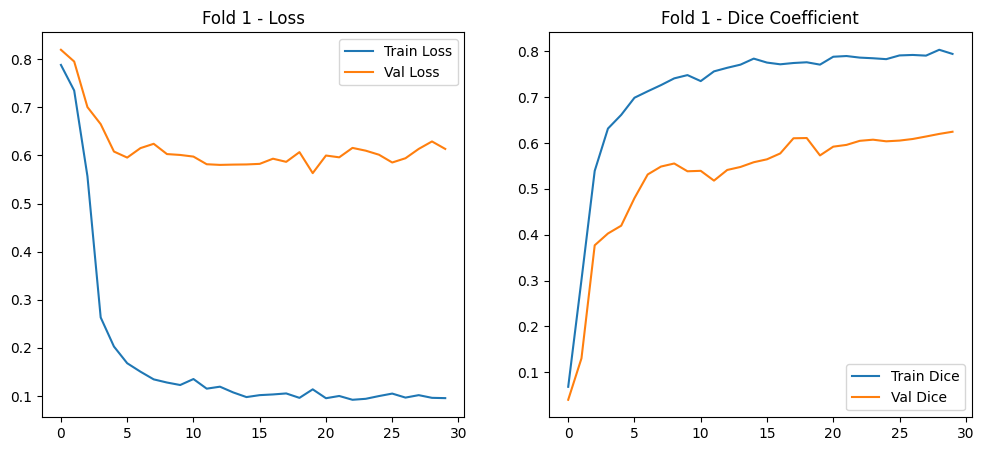

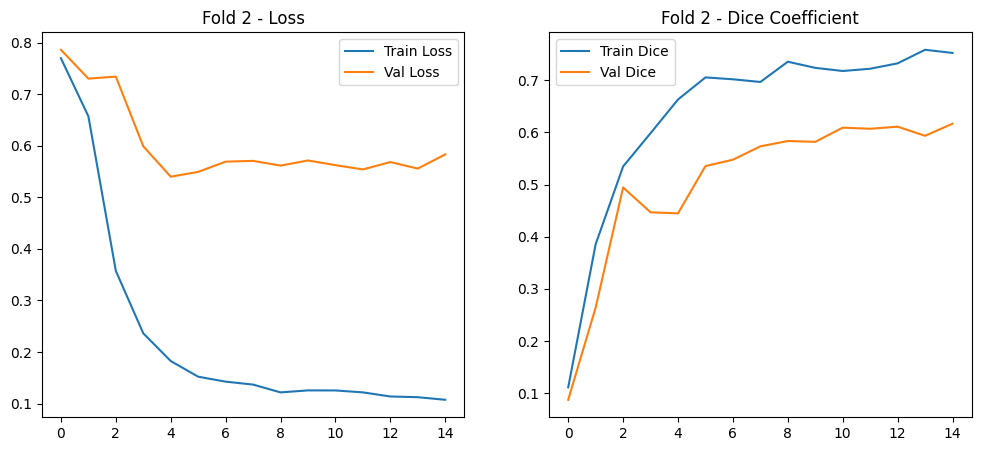

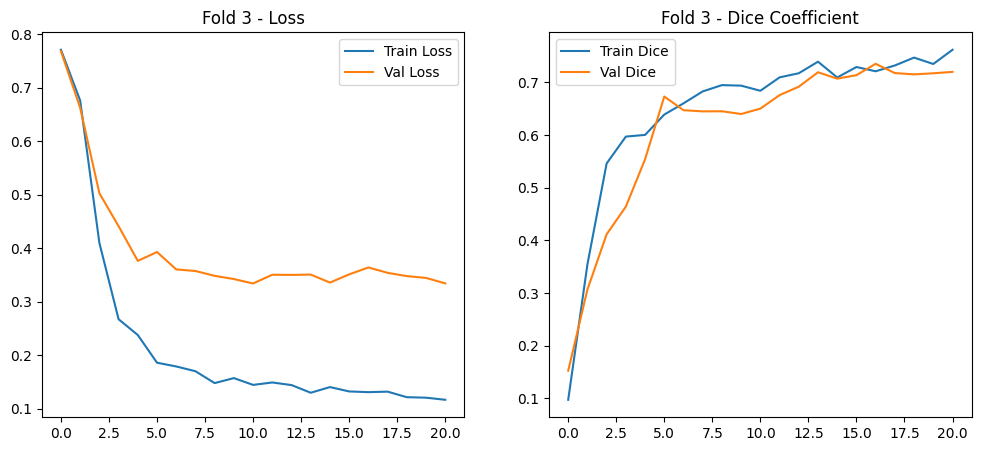

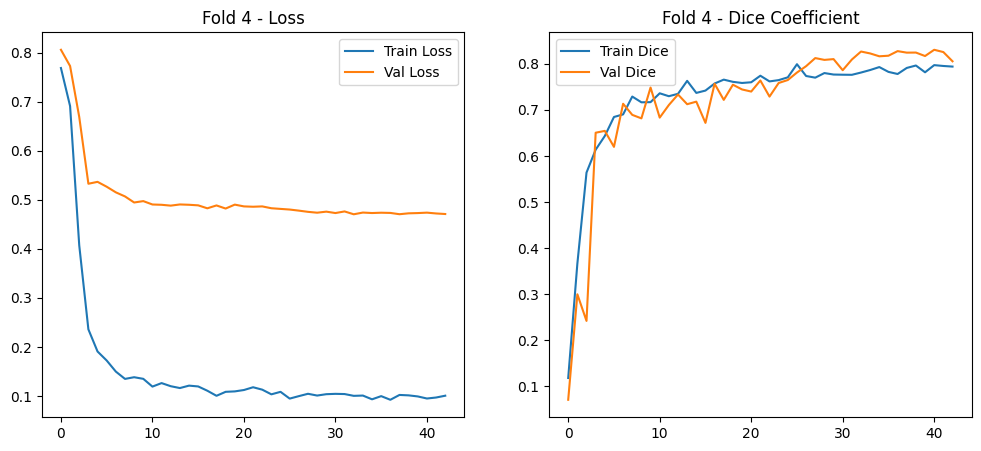

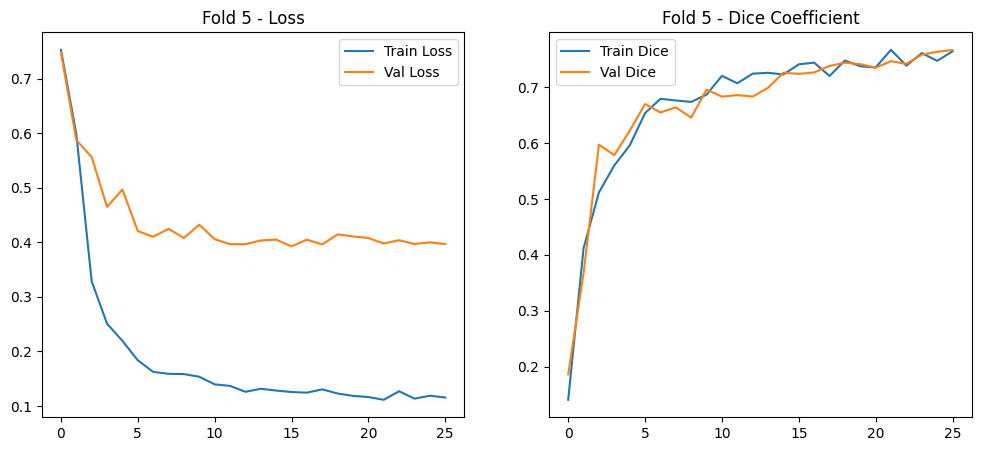

Showing results from Fold 4, which had the best validation Dice score.


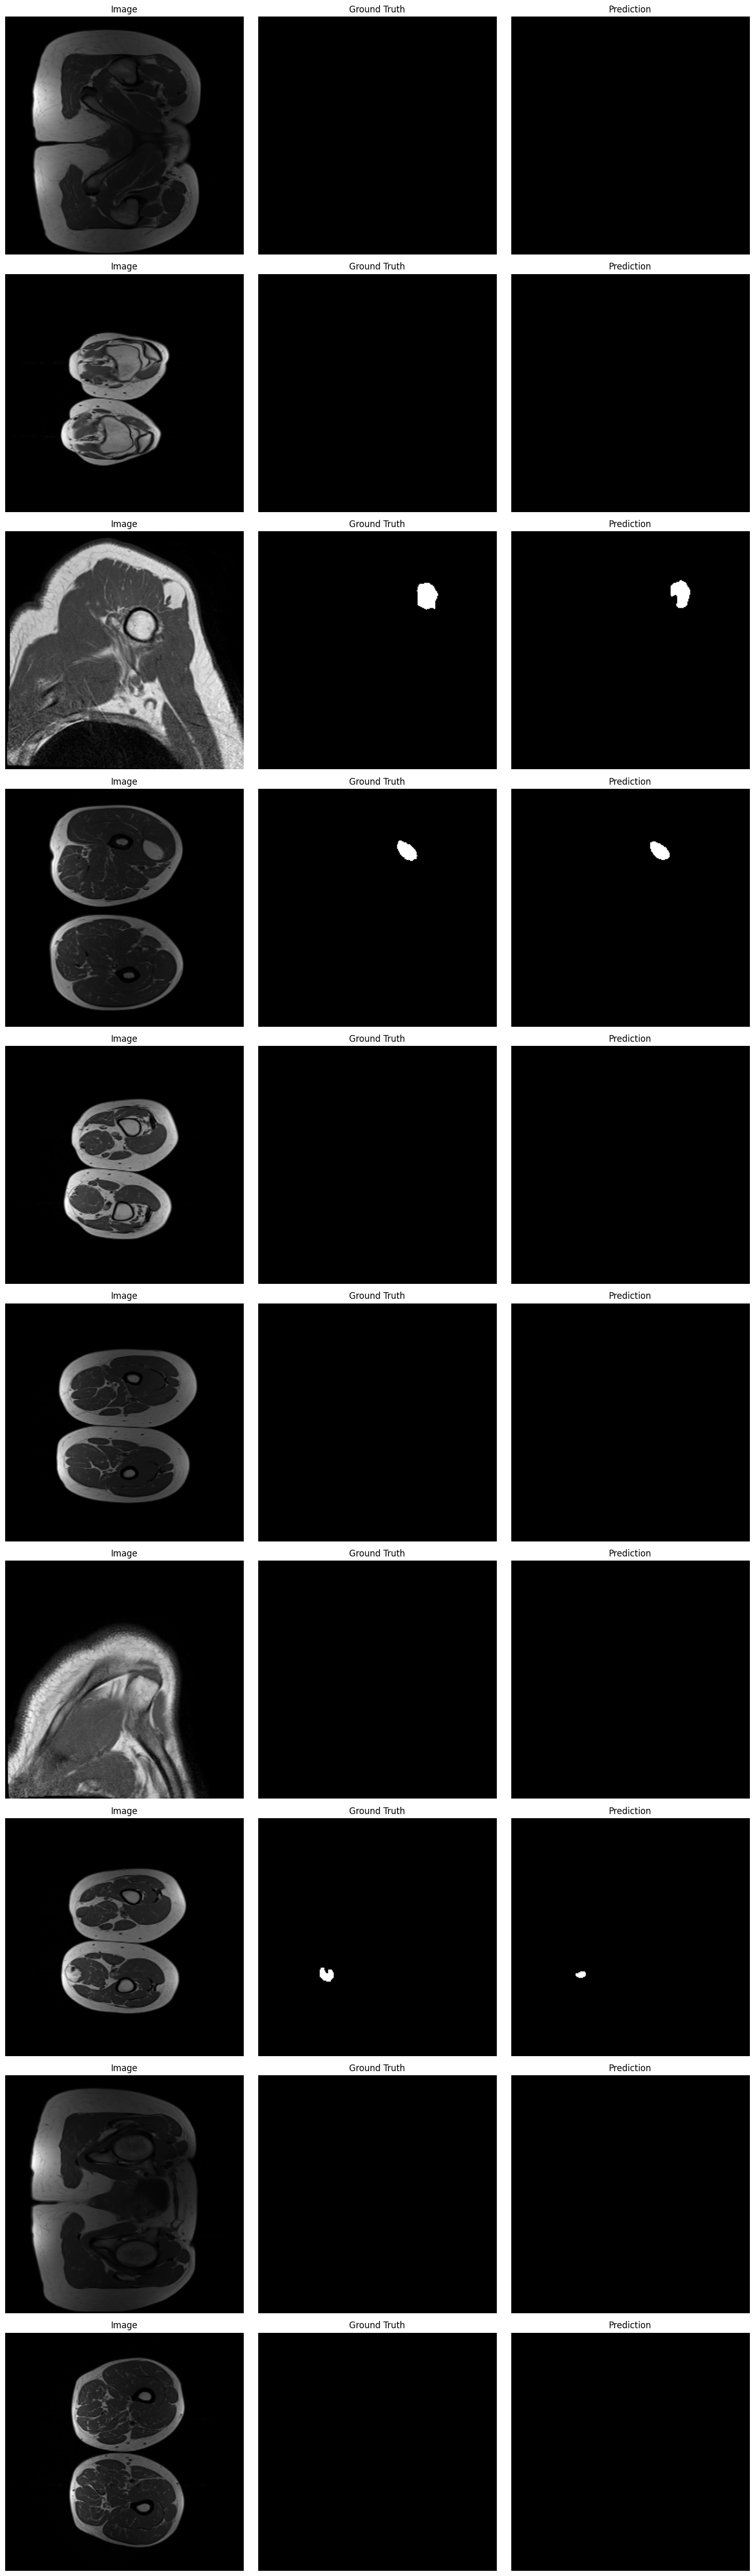

--- Cross-Validation Results ---
Fold 1: Best Val Loss = 0.5632, Best Val Dice = 0.6246
Fold 2: Best Val Loss = 0.5400, Best Val Dice = 0.6166
Fold 3: Best Val Loss = 0.3343, Best Val Dice = 0.7354
Fold 4: Best Val Loss = 0.4706, Best Val Dice = 0.8305
Fold 5: Best Val Loss = 0.3928, Best Val Dice = 0.7663
Average Best Val Loss: 0.4602 +/- 0.0866
Average Best Val Dice: 0.7147 +/- 0.0828


In [9]:
# Plotting Training History
for i, result in enumerate(fold_results):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(result['history']['train_loss'], label='Train Loss')
    plt.plot(result['history']['val_loss'], label='Val Loss')
    plt.title(f'Fold {i+1} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(result['history']['train_dice'], label='Train Dice')
    plt.plot(result['history']['val_dice'], label='Val Dice')
    plt.title(f'Fold {i+1} - Dice Coefficient')
    plt.legend()
    plt.show()

# Displaying Qualitative Results from the best model of a fold
best_fold_idx = np.argmax([max(r['history']['val_dice']) for r in fold_results])
print(f"Showing results from Fold {best_fold_idx+1}, which had the best validation Dice score.")

# Load the best model from the best fold
best_model_path = fold_results[best_fold_idx]['model_path']
model = build_model().to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Get the validation data from that fold
val_patients = fold_results[best_fold_idx]['val_patients']
val_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in val_patients]
val_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in val_patients]
val_dataset = LipomaDataset(image_paths=val_images, mask_paths=val_masks, transform=val_transform,
                            global_patient_slices=global_patient_slices)
val_loader = DataLoader(val_dataset, batch_size=NUM_PREDICTION_EXAMPLES, shuffle=True)


with torch.no_grad():
    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)
    preds = torch.sigmoid(model(images))

    # Reverse ImageNet normalization for display
    inv_mean = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
    inv_std = torch.tensor(IMAGENET_STD, device=device).view(1, 3, 1, 1)
    images_denorm = (images * inv_std + inv_mean).clamp(0, 1)

    plt.figure(figsize=(15, 5 * NUM_PREDICTION_EXAMPLES))
    for i in range(NUM_PREDICTION_EXAMPLES):
        plt.subplot(NUM_PREDICTION_EXAMPLES, 3, i*3 + 1)
        plt.imshow(images_denorm[i].cpu()[1], cmap='gray')  # center slice
        plt.title(f'Image')
        plt.axis('off')

        plt.subplot(NUM_PREDICTION_EXAMPLES, 3, i*3 + 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Ground Truth')
        plt.axis('off')

        plt.subplot(NUM_PREDICTION_EXAMPLES, 3, i*3 + 3)
        plt.imshow(preds[i].cpu().squeeze() > 0.5, cmap='gray')
        plt.title(f'Prediction')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Cross-Validation Results Summary
print('--- Cross-Validation Results ---')
final_val_dices = [max(r['history']['val_dice']) for r in fold_results]
final_val_losses = [min(r['history']['val_loss']) for r in fold_results]

for i in range(len(fold_results)):
    print(f'Fold {i+1}: Best Val Loss = {final_val_losses[i]:.4f}, Best Val Dice = {final_val_dices[i]:.4f}')

print(f'Average Best Val Loss: {np.mean(final_val_losses):.4f} +/- {np.std(final_val_losses):.4f}')
print(f'Average Best Val Dice: {np.mean(final_val_dices):.4f} +/- {np.std(final_val_dices):.4f}')

--- Cross-Validation Results --- prev
Fold 1: Best Val Loss = 0.6183, Best Val Dice = 0.6404
Fold 2: Best Val Loss = 0.5076, Best Val Dice = 0.7052
Fold 3: Best Val Loss = 0.3284, Best Val Dice = 0.7520
Fold 4: Best Val Loss = 0.4279, Best Val Dice = 0.8569
Fold 5: Best Val Loss = 0.4033, Best Val Dice = 0.7875
Average Best Val Loss: 0.4571 +/- 0.0988
Average Best Val Dice: 0.7484 +/- 0.0733

=== Final Test Set Evaluation ===
Fold 1: Test Dice = 0.7160 | With TTA+PP = 0.7484
Fold 2: Test Dice = 0.6683 | With TTA+PP = 0.6998
Fold 3: Test Dice = 0.7113 | With TTA+PP = 0.7189
Fold 4: Test Dice = 0.6232 | With TTA+PP = 0.5909
Fold 5: Test Dice = 0.5057 | With TTA+PP = 0.5145